In [1]:
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import sys

project_root = 'C:/Code/Github/GLM-analysis/'
if project_root not in sys.path:
    sys.path.append(project_root)

from handlers.DataHandlerEncoding import DataHandlerEncoding as datafun
from analysis.AnalysisManagerEncoding import AnalysisManagerEncoding as analysisfun
from utils.Plotter import Plotter as plotterfun
from utils.general_stats import GeneralStats



In [2]:
data_handler = datafun(data=None)  # Pass any initial data if needed

info_dir = 'W:\Connie/results\Bassi2025\data'
datasets, mouse_dates_keys = data_handler.load_info(info_dir)

#remove datasets for now while some are still running - finished: 0,1,2,3,4,5,6,7,11,14
# Indices to remove (example: remove datasets at indices 0 and 2)
remove_indices = list(set(range(0,25)) - set([0,1,2,3,4,5,6,7,11,14])) #[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24] #[2,3,8,18]

# Remove indices from both lists
datasets = [dat for i, dat in enumerate(datasets) if i not in remove_indices]
mouse_dates_keys = [key for i, key in enumerate(mouse_dates_keys) if i not in remove_indices]


model_type = 'GLM_3nmf_pre'
results_pre = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[5]) #1-4 to load 10
model_type = 'GLM_3nmf_passive'
results_pass = data_handler.process_multiple_datasets(datasets, model_type, results_type='results_updated',models_to_load=[5])

dir = os.path.join('W:\Connie/results\Bassi2025\data')
#load significant sound/opto neurons
opto, sound, mouse_dates, significant_neurons, mod_indices = data_handler.load_sound_opto_data(dir, set_diff = True, exclude = "HE1-00_2023-05-30")

Processing dataset: HA11-1R_2023-05-05
poss_model_5_data_cluster_0.pkl
poss_model_5_data_cluster_1.pkl
poss_model_5_data_cluster_2.pkl
poss_model_5_data_cluster_3.pkl
poss_model_5_data_cluster_4.pkl
poss_model_5_data_cluster_5.pkl
poss_model_5_data_cluster_6.pkl
poss_model_5_data_cluster_7.pkl
poss_model_5_data_cluster_8.pkl
poss_model_5_data_cluster_9.pkl
poss_model_5_data_cluster_10.pkl
poss_model_5_data_cluster_11.pkl
poss_model_5_data_cluster_12.pkl
poss_model_5_data_cluster_13.pkl
poss_model_5_data_cluster_14.pkl
poss_model_5_data_cluster_15.pkl
poss_model_5_data_cluster_16.pkl
poss_model_5_data_cluster_17.pkl
poss_model_5_data_cluster_18.pkl
poss_model_5_data_cluster_19.pkl
poss_model_5_data_cluster_20.pkl
poss_model_5_data_cluster_21.pkl
poss_model_5_data_cluster_22.pkl
poss_model_5_data_cluster_23.pkl
poss_model_5_data_cluster_24.pkl
poss_model_5_data_cluster_25.pkl
poss_model_5_data_cluster_26.pkl
poss_model_5_data_cluster_27.pkl
poss_model_5_data_cluster_28.pkl
poss_model_5_d

In [5]:
del results_pre['HA2-1L_2023-04-28']

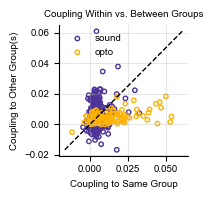

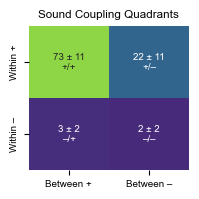

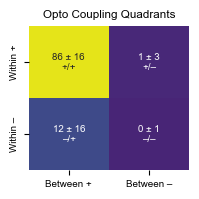

Chi-square test between sound and opto:
  χ² = 42.07, p = 3.877e-09, dof = 3
  Contingency Table:
       +/+  +/–  –/+  –/–
sound  542  187   16   12
opto   113    2    9    1
Permutation test p-value: 0, observed stat: 0.448
sound: p=0.0258, stat=0.000
opto: p=0.0002, stat=0.008
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


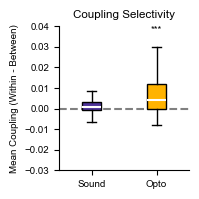

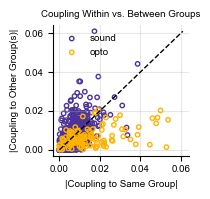

sound: p=0.7025, stat=-0.000
opto: p=0.0002, stat=0.008
Bonferroni corrected alpha threshold: 0.02500
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


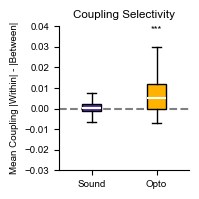

In [12]:
all_results = results_pass
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive/' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)

#initialize classes
plotter = plotterfun(data = None, save_results= save_results)
stats = GeneralStats()  # instantiate it
analysis_manager = analysisfun(data = None, plotter=plotter)

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_opto_vs_sound_coupling_{mode}.pdf', #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)

quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df,
    groups=['sound', 'opto'],
    save_dir=save_results,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'viridis'
)

p_value, observed_stat, permuted_stats = stats.permutation_test_quadrants(quad_stats['sound']['raw_counts'], quad_stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{mode}.pdf')


# now look at absolute value of coupling betas
mode = 'mean_abs'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_opto_vs_sound_coupling_{mode}.pdf',
    mode = mode
)

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = ['Sound','Opto'],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{mode}.pdf')

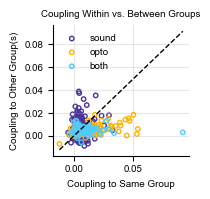

sound: p=0.3530, stat=0.000
opto: p=0.0002, stat=0.007
both: p=0.0006, stat=0.005
Bonferroni corrected alpha threshold: 0.01667
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


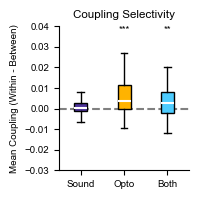

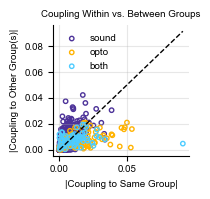

sound: p=0.0544, stat=-0.000
opto: p=0.0002, stat=0.008
both: p=0.0010, stat=0.004
Bonferroni corrected alpha threshold: 0.01667
Saving stats to W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive


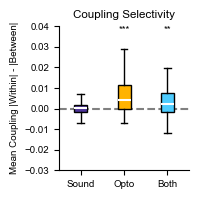

In [10]:
all_results = results_pass
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/passive/' #f'V:/Connie/results/glm/2025/updated'
os.makedirs(save_results, exist_ok=True)
groups_to_plot = ['sound','opto','both']#['sound','opto','both','unmod']
group_string = "_".join(groups_to_plot)

groups_to_plot2 = ['sound','opto','both']#['unmod','sound','opto','both']
group_string2 = "_".join(groups_to_plot2)


#initialize classes
plotter = plotterfun(data = None, save_results= save_results)
stats = GeneralStats()  # instantiate it
analysis_manager = analysisfun(data = None, plotter=plotter)

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = groups_to_plot2)

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_{group_string2}_coupling_{mode}.pdf', #'pooled_opto_vs_sound_coupling.pdf'
    mode = mode
)

# quad_stats = plotter.plot_quadrant_heatmap_across_datasets(
#     combined_df=coupling_df,
#     groups=groups_to_plot,
#     save_dir=save_results,
#     figsize=(2,2),
#     decimal_places=0,
#     vmax = 90,
#     colormap = 'viridis'
# )

# p_value, observed_stat, permuted_stats = stats.permutation_test_quadrants(quad_stats['sound']['raw_counts'], quad_stats['opto']['raw_counts'], n_permutations=1000, seed=42) #stats['sound']['mean'].reshape(2,2)
# print(f"Permutation test p-value: {p_value:.4g}, observed stat: {observed_stat:.3f}")

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = [g.capitalize() for g in groups_to_plot],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{group_string}_{mode}.pdf')


# now look at absolute value of coupling betas
mode = 'mean_abs'  #'mean' 'median'

coupling_df = analysis_manager.wrapper_dataset_compute_within_between_coupling(all_results,significant_neurons, mode = mode, groups_to_plot = groups_to_plot2)

plotter.plot_within_between_scatter(
    coupling_df,
    group_colors=plotter.group_colors,
    title='Coupling Within vs. Between Groups',
    figsize=(2.0, 2.0),
    save_path=f'{save_results}scatter_{group_string2}_coupling_{mode}.pdf',
    mode = mode
)

summary = plotter.plot_group_coupling_differences(coupling_df, mode= mode, paired=True, ylim =(-.03,0.04), figure_size=(2,2),
                                        group_order = [g.capitalize() for g in groups_to_plot],group_colors= plotter.group_colors, plot_type='box',width = 0.3, showfliers=False,
                                        save_path = f'{save_results}coupling_selectivity_boxplot_{group_string}_{mode}.pdf')

In [16]:
del results_pass['HA2-1L_2023-04-28']

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

def plot_active_passive_quadrant_difference(
        quad_stats_active,
        quad_stats_passive,
        save_dir=None,
        figsize=(3, 3),
        decimal_places=0,
        vmax=50,
        colormap='coolwarm'
    ):

    mpl.rcParams['pdf.fonttype'] = 42
    plt.rcParams.update({'font.size': 7, 'font.family': 'arial'})

    quadrant_labels = np.array([["+/+", "+/–"], ["–/+", "–/–"]])

    groups = quad_stats_active.keys()

    results = {}

    for group in groups:

        active_counts = quad_stats_active[group]['raw_counts']   # datasets x 4
        passive_counts = quad_stats_passive[group]['raw_counts'] # datasets x 4

        # Convert to fractions per dataset
        active_frac = active_counts / active_counts.sum(axis=1, keepdims=True) * 100
        passive_frac = passive_counts / passive_counts.sum(axis=1, keepdims=True) * 100

        # Difference per dataset
        diff = active_frac - passive_frac

        mean_diff = np.nanmean(diff, axis=0)
        std_diff = np.nanstd(diff, axis=0)

        results[group] = {
            'mean_diff': mean_diff,
            'std_diff': std_diff,
            'all_dataset_diff': diff
        }

        # Reshape to 2x2 for plotting
        mean_matrix = mean_diff.reshape(2, 2)
        std_matrix = std_diff.reshape(2, 2)

        label_matrix = np.array([
            [
                f"{mean_matrix[i,j]:.{decimal_places}f} ± {std_matrix[i,j]:.{decimal_places}f}\n{quadrant_labels[i,j]}"
                for j in range(2)
            ] for i in range(2)
        ])

        plt.figure(figsize=figsize)
        sns.heatmap(
            mean_matrix,
            annot=label_matrix,
            fmt='',
            cmap=colormap,
            center=0,
            cbar=False,
            vmin=-vmax,
            vmax=vmax,
            xticklabels=["Between +", "Between –"],
            yticklabels=["Within +", "Within –"]
        )

        plt.title(f"{group.capitalize()}:\nActive – Passive (%)", fontsize=7)
        plt.tight_layout()

        if save_dir:
            plt.savefig(f"{save_dir}/{group}_active_minus_passive_heatmap.pdf", dpi=300)

        plt.show()

    return results


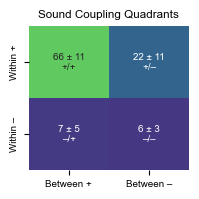

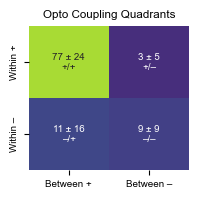

Chi-square test between sound and opto:
  χ² = 25.60, p = 1.156e-05, dof = 3
  Contingency Table:
       +/+  +/–  –/+  –/–
sound  466  178   38   35
opto    88    4   10    7


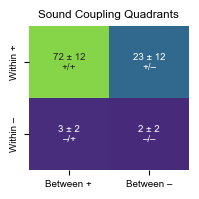

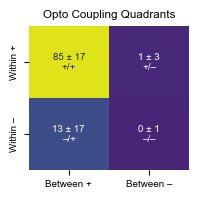

Chi-square test between sound and opto:
  χ² = 38.81, p = 1.9e-08, dof = 3
  Contingency Table:
       +/+  +/–  –/+  –/–
sound  509  182   14   12
opto    98    2    8    1


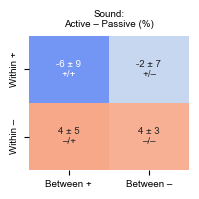

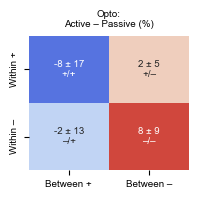

In [32]:
all_results = results_pass
mode = 'mean'  #'mean' 'median'
save_results = f'W:\Connie/results\Bassi2025\glm_coupling/all_neuron_coupling/' #f'V:/Connie/results/glm/2025/updated'
# os.makedirs(save_results, exist_ok=True)

coupling_df_pass = analysis_manager.wrapper_dataset_compute_within_between_coupling(results_pass,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])
coupling_df_act = analysis_manager.wrapper_dataset_compute_within_between_coupling(results_pre,significant_neurons, mode = mode, groups_to_plot = ['sound','opto'])

quad_stats_act = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df_act,
    groups=['sound', 'opto'],
    save_dir=None,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'viridis'
)

quad_stats_pass = plotter.plot_quadrant_heatmap_across_datasets(
    combined_df=coupling_df_pass,
    groups=['sound', 'opto'],
    save_dir=None,
    figsize=(2,2),
    decimal_places=0,
    vmax = 90,
    colormap = 'viridis'
)

quad_diff = plot_active_passive_quadrant_difference(
    quad_stats_active=quad_stats_act,
    quad_stats_passive=quad_stats_pass,
    vmax=10,
    figsize=(2,2),
    save_dir=save_results
)